In [1]:
import glob
import pandas as pd

In [15]:
conditions = [
    "serial_baseline",
    "2C",
    "2D",
    "2E",
]

dfs = {}
for cond in conditions:
    files = sorted(glob.glob(f"Result/{cond}_*.csv"))
    if not files:
        print(f"Ingen filer fundet for {cond}")
        dfs[cond] = pd.DataFrame()
        continue
    participants = [f.split(f"{cond}_")[-1].replace(".csv", "") for f in files]
    print(f"{cond}: {len(files)} deltagere -> {participants}")
    df_cond = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

    # Normalisér: serial recall-filer bruger 'serial_recall_score' i stedet for
    # 'serial_position_score' -- omdøb så alle betingelser har samme kolonnenavn
    if "serial_recall_score" in df_cond.columns and "serial_position_score" not in df_cond.columns:
        df_cond = df_cond.rename(columns={"serial_recall_score": "serial_position_score"})

    dfs[cond] = df_cond

df_ser  = dfs["serial_baseline"]
df_2C   = dfs["2C"]
df_2D   = dfs["2D"]
df_2E   = dfs["2E"]

serial_baseline: 3 deltagere -> ['Gustav', 'Katinka', 'Selma']
2C: 3 deltagere -> ['Gustav', 'Katinka', 'Selma']
2D: 3 deltagere -> ['Gustav', 'Katinka', 'Selma']
2E: 3 deltagere -> ['Gustav', 'Katinka', 'Selma']


In [9]:
remembered_words = []
not_remembered_words = []

for _, row in df_ser.iterrows():
    words = row["presented_words"].split()
    scores = row["serial_position_score"].split()

    for word, score in zip(words, scores):
        if score == "1":
            remembered_words.append(word)
        elif score == "0":
            not_remembered_words.append(word)

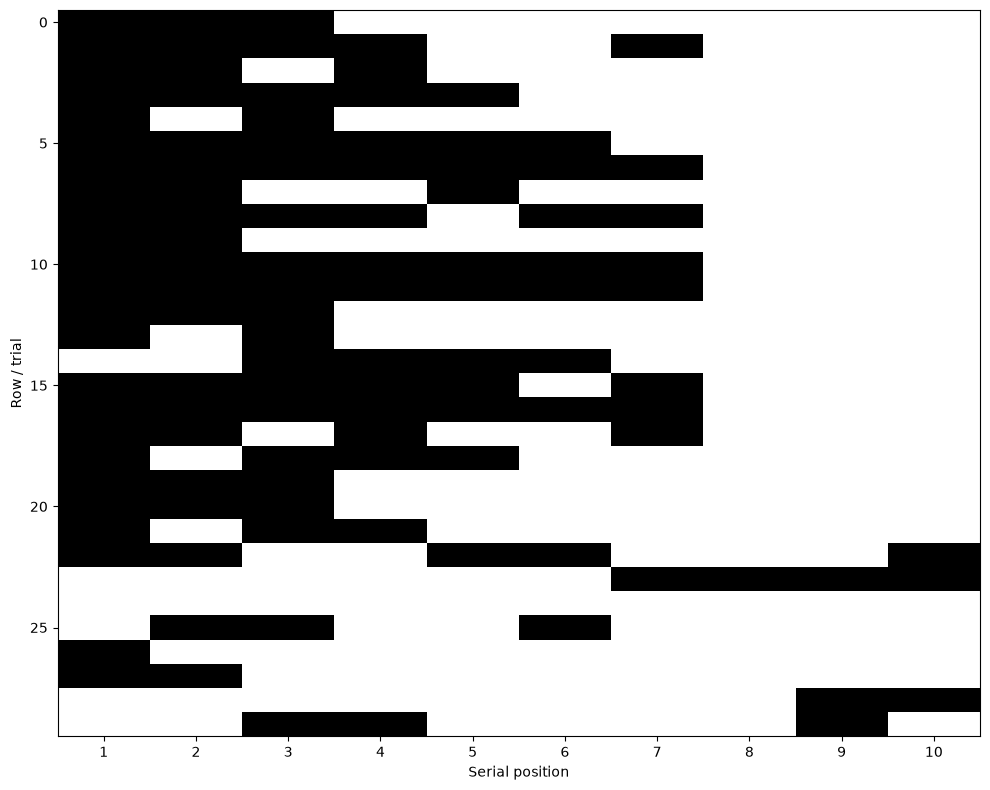

In [21]:
import matplotlib.pyplot as plt
import numpy as np
# Convert each space-separated score string into a list of integers
score_matrix = df_ser["serial_position_score"].apply(
    lambda x: [int(score) for score in x.split()]
).tolist()

# Convert to a NumPy array
score_matrix = np.array(score_matrix)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot the matrix as a raster
ax.imshow(
    score_matrix,
    aspect="auto",
    cmap="Greys",
    interpolation="none",
    vmin=0,
    vmax=1
)

ax.set_xlabel("Serial position")
ax.set_ylabel("Row / trial")
ax.set_xticks(range(10))
ax.set_xticklabels(range(1, 11))

plt.tight_layout()
plt.show()

In [42]:
from collections import Counter

not_remembered_words = []
all_words = []

for _, row in df_ser.iterrows():
    words = row["presented_words"].split()
    scores = row["serial_position_score"].split()

    for word, score in zip(words, scores):
        all_words.append(word)

        if score == "0":
            not_remembered_words.append(word)

# Count occurrences
not_remembered_counts = Counter(not_remembered_words)
total_counts = Counter(all_words)

normalized_counts = {
    word: not_remembered_counts.get(word, 0) / count
    for word, count in total_counts.items()
}
normalized_counts = {
    word: not_remembered_counts.get(word, 0) / count
    for word, count in total_counts.items()
    if count >= 2
}

In [44]:
for word, rate in sorted(
    normalized_counts.items(),
    key=lambda item: total_counts[item[0]],
    reverse=True
):
    count = total_counts[word]
    correct = not_remembered_counts.get(word, 0)
    print(f"{word}: {rate:.2%} ({correct}/{count})")

to: 55.56% (10/18)
you: 58.82% (10/17)
the: 80.00% (12/15)
he: 75.00% (6/8)
your: 85.71% (6/7)
do: 57.14% (4/7)
of: 83.33% (5/6)
is: 66.67% (4/6)
was: 66.67% (4/6)
me: 66.67% (4/6)
for: 80.00% (4/5)
a: 40.00% (2/5)
we: 75.00% (3/4)
in: 75.00% (3/4)
that: 75.00% (3/4)
him: 100.00% (3/3)
at: 100.00% (3/3)
it: 100.00% (3/3)
lot: 66.67% (2/3)
have: 66.67% (2/3)
be: 33.33% (1/3)
pay: 33.33% (1/3)
as: 33.33% (1/3)
want: 33.33% (1/3)
same: 0.00% (0/3)
us: 100.00% (2/2)
had: 100.00% (2/2)
went: 100.00% (2/2)
by: 100.00% (2/2)
bus: 100.00% (2/2)
should: 100.00% (2/2)
my: 100.00% (2/2)
how: 50.00% (1/2)
does: 50.00% (1/2)
if: 50.00% (1/2)
his: 50.00% (1/2)
time: 50.00% (1/2)
who: 50.00% (1/2)
never: 50.00% (1/2)
no: 50.00% (1/2)
can: 50.00% (1/2)
not: 50.00% (1/2)
get: 50.00% (1/2)
did: 50.00% (1/2)
here: 0.00% (0/2)
need: 0.00% (0/2)
would: 0.00% (0/2)
told: 0.00% (0/2)
father: 0.00% (0/2)
this: 0.00% (0/2)


In [43]:
normalized_counts = dict(
    sorted(normalized_counts.items(), key=lambda item: item[1], reverse=True)
)

for word, proportion in normalized_counts.items():
    print(f"{word}: {proportion:.2%}")

us: 100.00%
had: 100.00%
went: 100.00%
him: 100.00%
by: 100.00%
bus: 100.00%
at: 100.00%
should: 100.00%
it: 100.00%
my: 100.00%
your: 85.71%
of: 83.33%
the: 80.00%
for: 80.00%
he: 75.00%
we: 75.00%
in: 75.00%
that: 75.00%
lot: 66.67%
is: 66.67%
was: 66.67%
have: 66.67%
me: 66.67%
you: 58.82%
do: 57.14%
to: 55.56%
how: 50.00%
does: 50.00%
if: 50.00%
his: 50.00%
time: 50.00%
who: 50.00%
never: 50.00%
no: 50.00%
can: 50.00%
not: 50.00%
get: 50.00%
did: 50.00%
a: 40.00%
be: 33.33%
pay: 33.33%
as: 33.33%
want: 33.33%
here: 0.00%
need: 0.00%
would: 0.00%
same: 0.00%
told: 0.00%
father: 0.00%
this: 0.00%


In [26]:
from collections import Counter

remembered_counts = Counter(remembered_words)
not_remembered_counts = Counter(not_remembered_words)
all_words = Counter(remembered_words + not_remembered_words)

# Convert to a regular dictionary, sorted by frequency (highest first)
remembered_dict = dict(remembered_counts.most_common())
# Convert to a regular dictionary, sorted by frequency (highest first)
not_remembered_dict = dict(not_remembered_counts.most_common())

print(remembered_dict)
print(not_remembered_dict)

{'to': 8, 'you': 7, 'a': 3, 'same': 3, 'the': 3, 'do': 3, 'here': 2, 'need': 2, 'would': 2, 'be': 2, 'pay': 2, 'told': 2, 'as': 2, 'me': 2, 'he': 2, 'father': 2, 'is': 2, 'want': 2, 'this': 2, 'was': 2, 'will': 1, 'how': 1, 'does': 1, 'if': 1, 'his': 1, 'clean': 1, 'maybe': 1, 'really': 1, 'sad': 1, 'lot': 1, 'we': 1, 'ever': 1, 'with': 1, 'time': 1, 'now': 1, 'cup': 1, 'of': 1, 'has': 1, 'mean': 1, 'french': 1, 'kind': 1, 'no': 1, 'anyone': 1, 'are': 1, 'for': 1, 'what': 1, 'train': 1, 'can': 1, 'change': 1, 'older': 1, 'your': 1, 'large': 1, 'must': 1, 'days': 1, 'have': 1, 'not': 1, 'could': 1, 'get': 1, 'in': 1, 'that': 1, 'twenty': 1, 'think': 1, 'miss': 1, 'funny': 1, 'money': 1, 'out': 1, 'did': 1, 'school': 1, 'son': 1, 'please': 1, 'much': 1, 'who': 1, 'gets': 1, 'blow': 1, 'things': 1, 'buy': 1, 'first': 1, 'never': 1, 'fear': 1, 'year': 1}
{'the': 12, 'to': 10, 'you': 10, 'he': 6, 'your': 6, 'of': 5, 'do': 4, 'is': 4, 'was': 4, 'for': 4, 'me': 4, 'him': 3, 'in': 3, 'at': 3, 

In [11]:
not_remembered_words

['lot',
 'any',
 'hard',
 'us',
 'had',
 'do',
 'is',
 'to',
 'you',
 'safe',
 'to',
 'was',
 'went',
 'felt',
 'eat',
 'the',
 'time',
 'him',
 'had',
 'him',
 'park',
 'women',
 'of',
 'each',
 'to',
 'see',
 'he',
 'who',
 'saw',
 'your',
 'have',
 'you',
 'give',
 'smile',
 'to',
 'he',
 'on',
 'a',
 'by',
 'in',
 'able',
 'pay',
 'the',
 'for',
 'as',
 'never',
 'make',
 'too',
 'ill',
 'your',
 'garden',
 'of',
 'word',
 'idea',
 'be',
 'the',
 'you',
 'saved',
 'path',
 'bus',
 'in',
 'your',
 'to',
 'at',
 'the',
 'should',
 'me',
 'tell',
 'many',
 'to',
 'her',
 'an',
 'went',
 'dinner',
 'far',
 'it',
 'the',
 'to',
 'have',
 'was',
 'by',
 'the',
 'is',
 'your',
 'go',
 'that',
 'for',
 'one',
 'at',
 'good',
 'lot',
 'a',
 'we',
 'bus',
 'want',
 'pocket',
 'the',
 'us',
 'ran',
 'you',
 'take',
 'stay',
 'put',
 'my',
 'your',
 'get',
 'of',
 'he',
 'and',
 'action',
 'at',
 'he',
 'should',
 'to',
 'do',
 'just',
 'new',
 'did',
 'to',
 'the',
 'me',
 'me',
 'she',
 'he'

In [10]:
remembered_words

['will',
 'how',
 'does',
 'here',
 'a',
 'need',
 'if',
 'his',
 'would',
 'same',
 'clean',
 'maybe',
 'be',
 'really',
 'pay',
 'sad',
 'the',
 'told',
 'lot',
 'as',
 'do',
 'we',
 'ever',
 'need',
 'me',
 'with',
 'time',
 'you',
 'now',
 'he',
 'cup',
 'of',
 'has',
 'mean',
 'would',
 'same',
 'french',
 'be',
 'kind',
 'no',
 'pay',
 'anyone',
 'to',
 'are',
 'you',
 'for',
 'to',
 'to',
 'told',
 'a',
 'what',
 'you',
 'train',
 'father',
 'can',
 'change',
 'older',
 'to',
 'you',
 'your',
 'large',
 'must',
 'here',
 'is',
 'me',
 'as',
 'days',
 'have',
 'not',
 'want',
 'you',
 'could',
 'get',
 'this',
 'in',
 'this',
 'that',
 'twenty',
 'think',
 'miss',
 'the',
 'a',
 'funny',
 'to',
 'to',
 'money',
 'out',
 'did',
 'school',
 'son',
 'want',
 'do',
 'same',
 'please',
 'much',
 'you',
 'who',
 'was',
 'father',
 'gets',
 'blow',
 'things',
 'to',
 'buy',
 'he',
 'do',
 'is',
 'to',
 'was',
 'you',
 'first',
 'the',
 'never',
 'fear',
 'year']